In [17]:
!pip install nx-cugraph-cu12 --extra-index-url https://pypi.nvidia.com
import os
os.environ['NX_CUGRAPH_AUTOCONFIG'] = 'True'

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [1]:
%env NX_CUGRAPH_AUTOCONFIG=True

import networkx as nx
print(f"using networkx version {nx.__version__}")

nx.config.warnings_to_ignore.add("cache")

env: NX_CUGRAPH_AUTOCONFIG=True
using networkx version 3.6.1


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import math


In [1]:
pip install networkx matplotlib numpy

# Question 1


## Question 1.1

In [27]:
# filename = "facebook_combined.txt"
url = "https://raw.githubusercontent.com/anwxwna/232E_sp26/refs/heads/main/facebook_combined.txt"
filename = "./facebook_combined.txt"
urllib.request.urlretrieve(url, filename)

G = nx.read_edgelist(filename, create_using=nx.Graph(), nodetype=int)

# Step 3: Basic info
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 4039
Number of edges: 88234


## Question 1.2

In [4]:
is_connected = nx.is_connected(G)
print(f"Is the network connected? {is_connected}")

if not is_connected:
    gcc = max(nx.connected_components(G), key=len)
    G_gcc = G.subgraph(gcc).copy()
else:
    G_gcc = G

print(f"Size of GCC - Nodes: {G_gcc.number_of_nodes()}, Edges: {G_gcc.number_of_edges()}")

Is the network connected? True
Size of GCC - Nodes: 4039, Edges: 88234


# Question 2
Find the diameter of the network. If the network is not connected, then find the
diameter of the GCC.

In [5]:
diameter = nx.diameter(G_gcc)
print(f"Diameter of the network (or GCC): {diameter}")

Diameter of the network (or GCC): 8


# Question 3
Plot the degree distribution of the facebook network and report the average
degree.

Average degree: 43.69


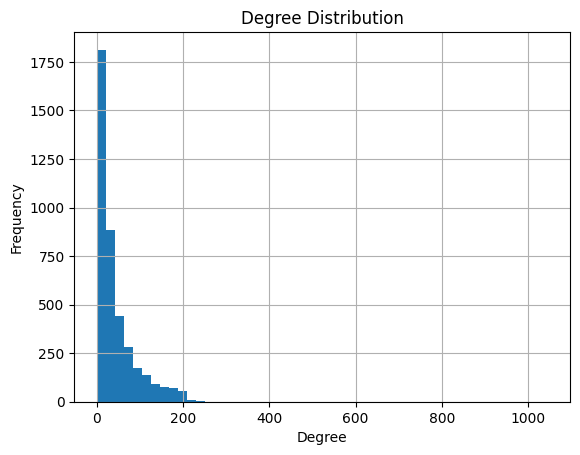

In [6]:
degrees = [d for n, d in G.degree()]
avg_degree = np.mean(degrees)
print(f"Average degree: {avg_degree:.2f}")

# Plot degree distribution
plt.figure()
plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# QUESTION 4:
Plot the degree distribution of Question 3 in a log-log scale. Try to fit a line to
the plot and estimate the slope of the line.

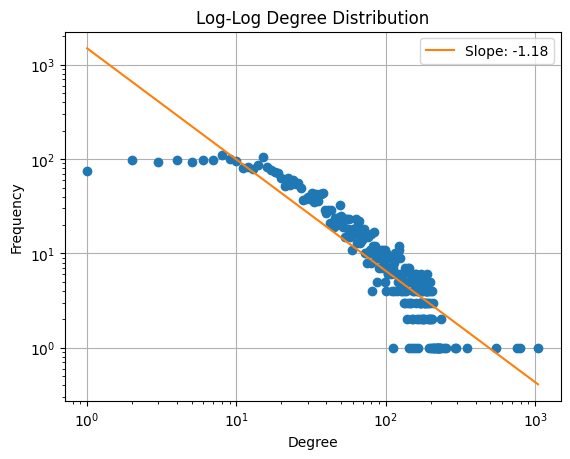

Estimated slope of the log-log plot: -1.18


In [7]:
degree_counts = np.bincount(degrees)
degree_values = np.nonzero(degree_counts)[0]
counts = degree_counts[degree_values]

plt.figure()
plt.loglog(degree_values, counts, marker='o', linestyle='None')
plt.title("Log-Log Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")

# Fit line to log-log plot
log_degrees = np.log(degree_values)
log_counts = np.log(counts)
slope, intercept = np.polyfit(log_degrees, log_counts, 1)
plt.plot(degree_values, np.exp(intercept) * degree_values**slope, label=f"Slope: {slope:.2f}")
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated slope of the log-log plot: {slope:.2f}")

# QUESTION 5:
Create a personalized network of the user whose ID is 1. How many nodes and
edges does this personalized network have?

In [8]:
target_node = 0  # user whose ID is 1
personalized_net = nx.ego_graph(G, target_node)  # ego_graph returns node + neighbors

pn_nodes = personalized_net.number_of_nodes()
pn_edges = personalized_net.number_of_edges()
print(f"Personalized Network Nodes: {pn_nodes}")
print(f"Personalized Network Edges: {pn_edges}")

Personalized Network Nodes: 348
Personalized Network Edges: 2866


# QUESTION 6:
What is the diameter of the personalized network? Please state a trivial upper
and lower bound for the diameter of the personalized network.

In [9]:
pn_diameter = nx.diameter(personalized_net)
print(f"Diameter of the Personalized Network: {pn_diameter}")

Diameter of the Personalized Network: 2


In [10]:
lower_bound = 1  # Minimum if everyone is directly connected
upper_bound = 2  # Max because all nodes are neighbors of center or each other
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: 1
Upper Bound: 2


# QUESTION 7:
In the context of the personalized network, what is the meaning of the diameter
of the personalized network to be equal to the upper bound you derived in Question 6. What is the
meaning of the diameter of the personalized network to be equal to the lower bound you derived in
Question 6 (assuming there are more than 3 nodes in the personalized network)?

In [11]:
if pn_diameter == upper_bound:
    print("Diameter equals upper bound: Some neighbors are not directly connected to each other.")
elif pn_diameter == lower_bound:
    print("Diameter equals lower bound: All neighbors are directly connected to each other (clique).")
else:
    print("Diameter is between bounds: Intermediate connectivity among neighbors.")

Diameter equals upper bound: Some neighbors are not directly connected to each other.


Since the diameter of the personalized network is equal to the upper bound (2), it means that the users are not directly connected to one another, but must go through the central user to reach others. That means the the network is not fully connected like a clique ,but has more of a star like structure where most friends are connected through the user

# QUESTION 8:
How many core nodes are there in the Facebook network. What is the average degree of the core nodes?

In [12]:
# Get degree of each node
node_degrees = dict(G.degree())

# Core nodes: nodes with degree > 200
core_nodes = [node for node, deg in node_degrees.items() if deg > 200]

# Number of core nodes
num_core_nodes = len(core_nodes)
print(f"Number of core nodes: {num_core_nodes}")

# Average degree of core nodes
avg_core_degree = np.mean([node_degrees[node] for node in core_nodes])
print(f"Average degree of core nodes: {avg_core_degree:.2f}")

Number of core nodes: 40
Average degree of core nodes: 279.38


# QUESTION 9:
For each of the above core node’s personalized network, find the community structure
using Fast-Greedy, Edge-Betweenness, and Infomap community detection algorithms. Compare
the modularity scores of the algorithms. For visualization purpose, display the community structure
of the core node’s personalized networks using colors. Nodes belonging to the same community
should have the same color and nodes belonging to different communities should have different
color. In this question, you should have 15 plots in total.

In [14]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 136.5 MB/s eta 0:00:00


In [14]:
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random

# From assignment specification, core nodes are given as:
# core node = node ID - 1
core_nodes = [0, 107, 348, 483, 1086]

# Helper function to plot communities
def plot_communities(G_personal, membership, title):
    pos = nx.spring_layout(G_personal, seed=42)
    communities = {}
    for idx, cluster_id in enumerate(membership):
        communities.setdefault(cluster_id, []).append(idx)

    colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
    random.shuffle(colors)

    plt.figure(figsize=(6, 6))
    for cluster_id, nodes in communities.items():
        node_list = [list(G_personal.nodes())[node_idx] for node_idx in nodes]
        nx.draw_networkx_nodes(G_personal, pos, nodelist=node_list, node_color=colors[cluster_id % len(colors)], label=f'Community {cluster_id}')
    nx.draw_networkx_edges(G_personal, pos, alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.legend()
    plt.show()

def fast_greedy(G_personal, core_node):
    G_ig = ig.Graph.TupleList(G_personal.edges(), directed=False)
    fg_clusters = G_ig.community_fastgreedy().as_clustering()
    modularity = G_ig.modularity(fg_clusters.membership)
    plot_communities(G_personal, fg_clusters.membership, f"Fast-Greedy (Core {core_node})")
    return modularity

def edge_betweenness(G_personal, core_node):
    G_ig = ig.Graph.TupleList(G_personal.edges(), directed=False)
    eb_clusters = G_ig.community_edge_betweenness().as_clustering()
    modularity = G_ig.modularity(eb_clusters.membership)
    plot_communities(G_personal, eb_clusters.membership, f"Edge-Betweenness (Core {core_node})")
    return modularity

def infomap(G_personal, core_node):
    G_ig = ig.Graph.TupleList(G_personal.edges(), directed=False)
    im_clusters = G_ig.community_infomap()
    modularity = G_ig.modularity(im_clusters.membership)
    plot_communities(G_personal, im_clusters.membership, f"Infomap (Core {core_node})")
    return modularity

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from networkx.algorithms.community import (
    greedy_modularity_communities,
    girvan_newman,
    modularity
)

# From assignment specification, core nodes are given as:
# core node = node ID - 1
core_nodes = [0, 107, 348, 483, 1086]

# Helper: convert list of community sets into membership list
def communities_to_membership(G_personal, communities):
    node_list = list(G_personal.nodes())
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    membership = [None] * len(node_list)

    for cluster_id, community in enumerate(communities):
        for node in community:
            membership[node_to_idx[node]] = cluster_id

    return membership

# Helper function to plot communities
def plot_communities(G_personal, membership, title):
    pos = nx.spring_layout(G_personal, seed=42)
    communities = {}
    node_list = list(G_personal.nodes())

    for idx, cluster_id in enumerate(membership):
        communities.setdefault(cluster_id, []).append(node_list[idx])

    colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
    random.shuffle(colors)

    plt.figure(figsize=(6, 6))
    for cluster_id, nodes in communities.items():
        nx.draw_networkx_nodes(
            G_personal,
            pos,
            nodelist=nodes,
            node_color=colors[cluster_id % len(colors)],
            label=f"Community {cluster_id}"
        )

    nx.draw_networkx_edges(G_personal, pos, alpha=0.5)
    plt.title(title)
    plt.axis("off")
    plt.legend()
    plt.show()

def fast_greedy(G_personal, core_node):
    communities = list(greedy_modularity_communities(G_personal))
    membership = communities_to_membership(G_personal, communities)
    mod = modularity(G_personal, communities)
    plot_communities(G_personal, membership, f"Fast-Greedy (Core {core_node})")
    return mod

# def edge_betweenness(G_personal, core_node):
#     # Girvan-Newman returns an iterator over hierarchical splits.
#     # Take the first split for a simple edge-betweenness partition.
#     comp = girvan_newman(G_personal)
#     communities = list(next(comp))
#     membership = communities_to_membership(G_personal, communities)
#     mod = modularity(G_personal, communities)
#     plot_communities(G_personal, membership, f"Edge-Betweenness (Core {core_node})")
#     return mod

def edge_betweenness(G_personal, core_node):
    comp = girvan_newman(G_personal)

    best_communities = None
    best_modularity = -1

    for communities in comp:
        communities = list(communities)
        mod = modularity(G_personal, communities)

        if mod > best_modularity:
            best_modularity = mod
            best_communities = communities

        # stop if every node becomes its own community
        if len(communities) >= G_personal.number_of_nodes():
            break

    membership = communities_to_membership(G_personal, best_communities)
    plot_communities(G_personal, membership, f"Edge-Betweenness (Core {core_node})")
    return best_modularity

# def infomap(G_personal, core_node):
#     raise NotImplementedError(
#         "Infomap is not available natively in NetworkX. "
#         "Use the external 'infomap' package, or replace this with another "
#         "NetworkX community method such as louvain_communities or asyn_lpa_communities."
#     )

=== Core node 0 ===


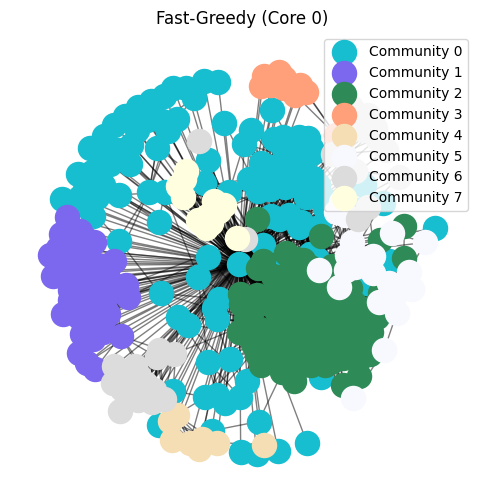

Fast-Greedy modularity: 0.4131


KeyboardInterrupt: 

In [15]:
for core in core_nodes:
    print(f"=== Core node {core} ===")
    G_personal = nx.ego_graph(G, core)

    mod_fg = fast_greedy(G_personal, core)
    print(f"Fast-Greedy modularity: {mod_fg:.4f}")

    mod_eb = edge_betweenness(G_personal, core)
    print(f"Edge-Betweenness modularity: {mod_eb:.4f}")

    mod_im = infomap(G_personal, core)
    print(f"Infomap modularity: {mod_im:.4f}")

# QUESTION 10:
For each of the core node’s personalized network (use same core nodes as
Question 9), remove the core node from the personalized network and find the community structure
of the modified personalized network. Use the same community detection algorithm as Question 9.
Compare the modularity score of the community structure of the modified personalized network with
the modularity score of the community structure of the personalized network of Question 9. For
visualization purpose, display the community structure of the modified personalized network using
colors. In this question, you should have 15 plots in total.

=== Core node 0 (Core node removed) ===


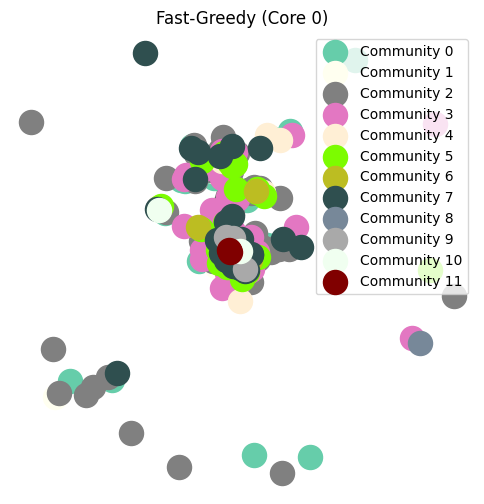

Fast-Greedy modularity (core removed): 0.4459


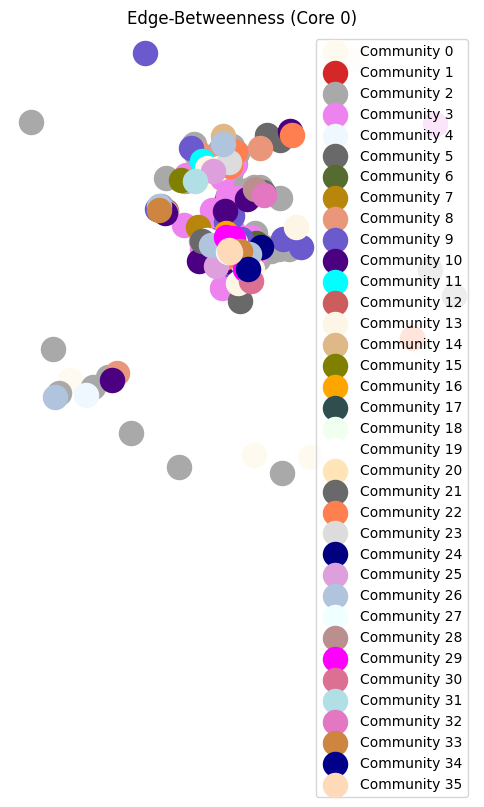

Edge-Betweenness modularity (core removed): 0.4161


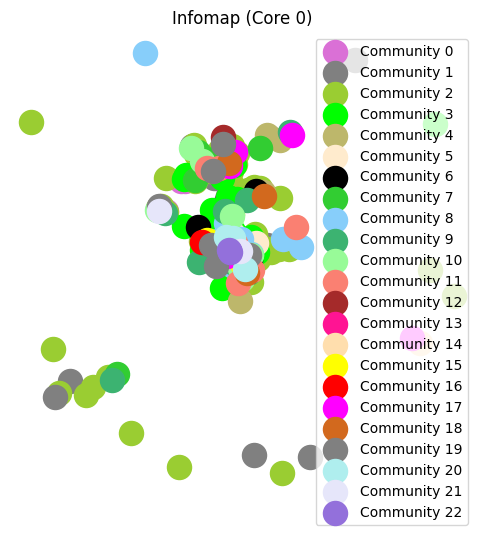

Infomap modularity (core removed): 0.4200
=== Core node 107 (Core node removed) ===


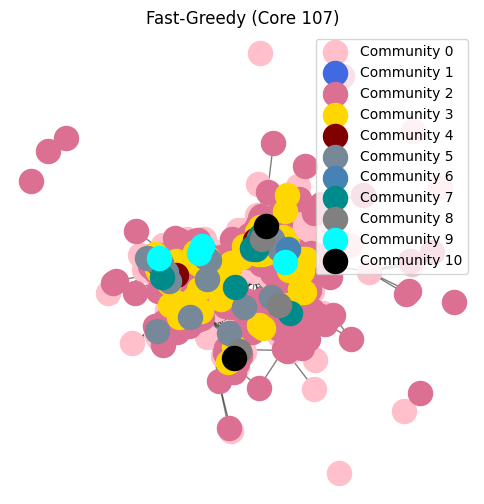

Fast-Greedy modularity (core removed): 0.4581


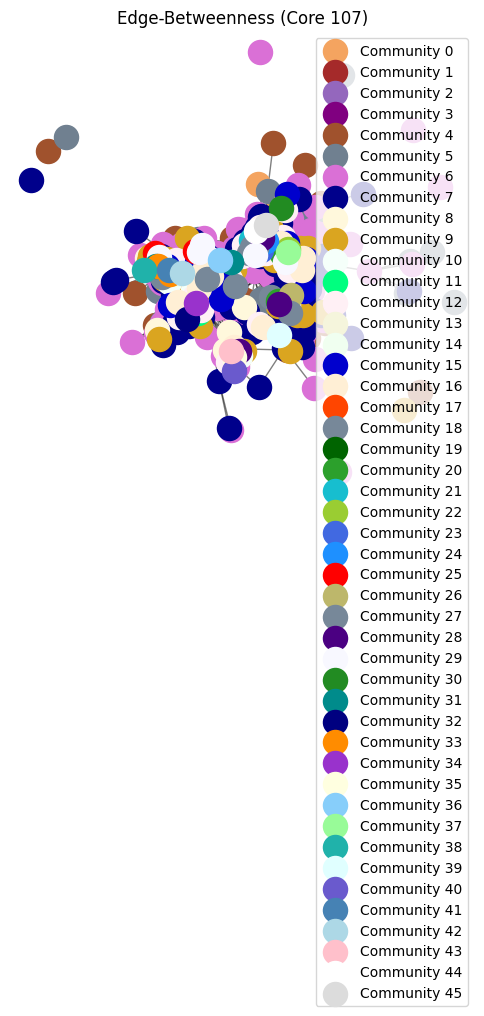

Edge-Betweenness modularity (core removed): 0.5213


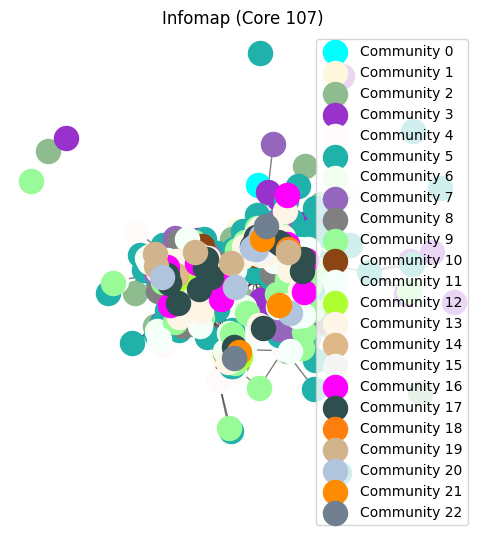

Infomap modularity (core removed): 0.5206
=== Core node 348 (Core node removed) ===


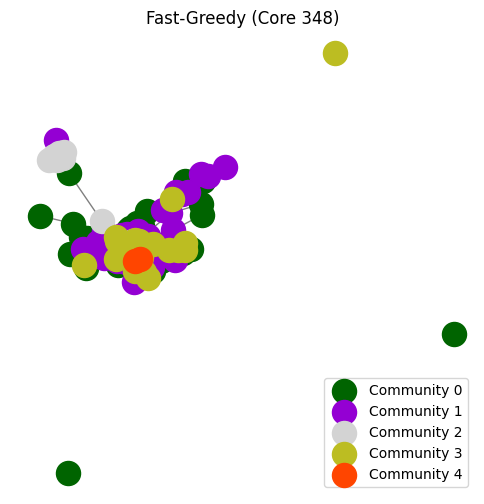

Fast-Greedy modularity (core removed): 0.2457


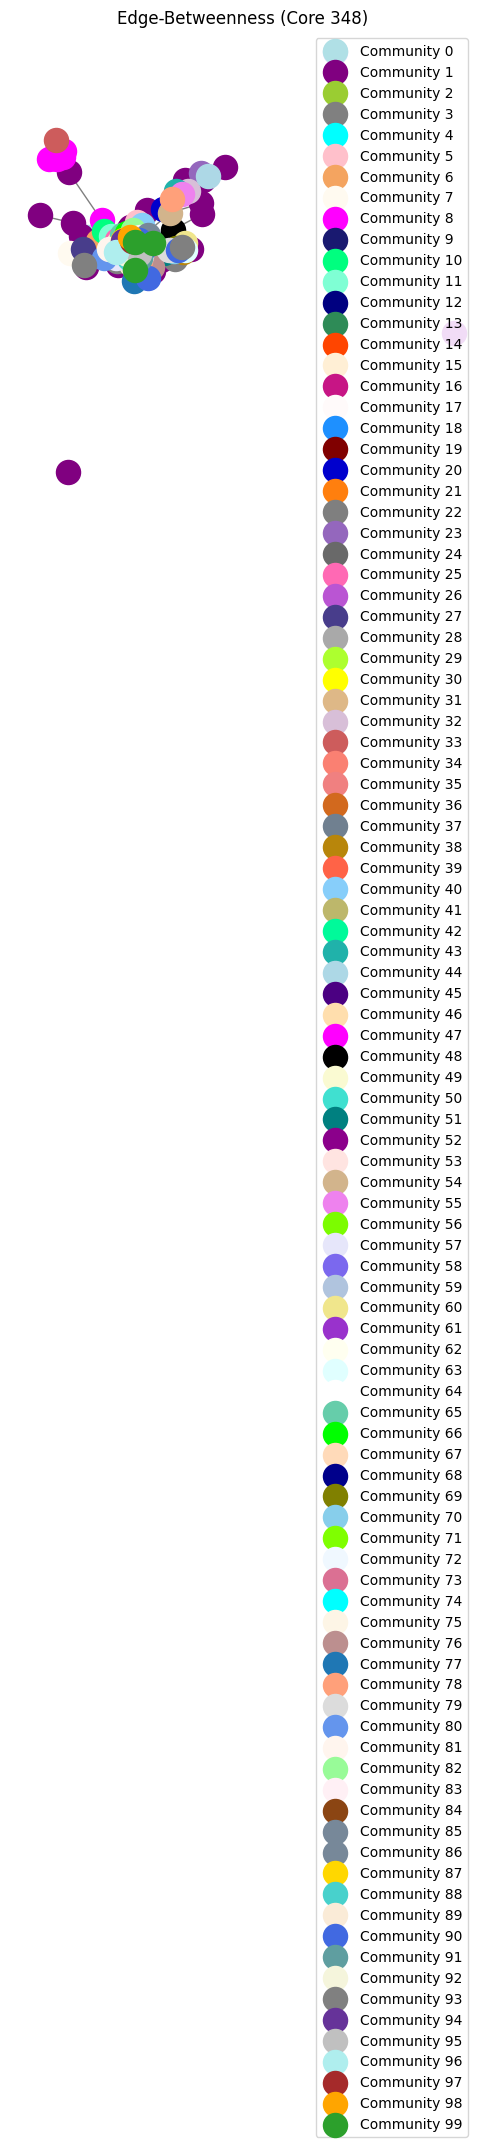

Edge-Betweenness modularity (core removed): 0.1506


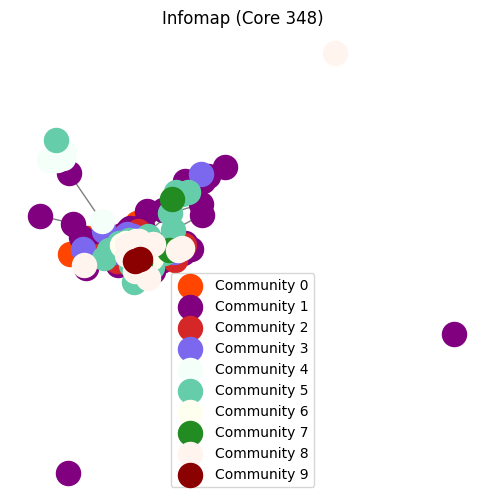

Infomap modularity (core removed): 0.2458
=== Core node 483 (Core node removed) ===


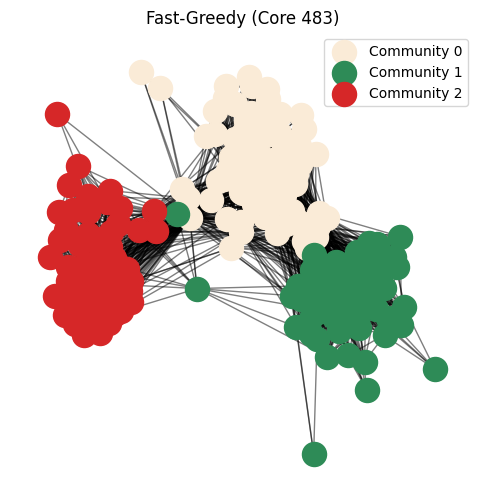

Fast-Greedy modularity (core removed): 0.5342


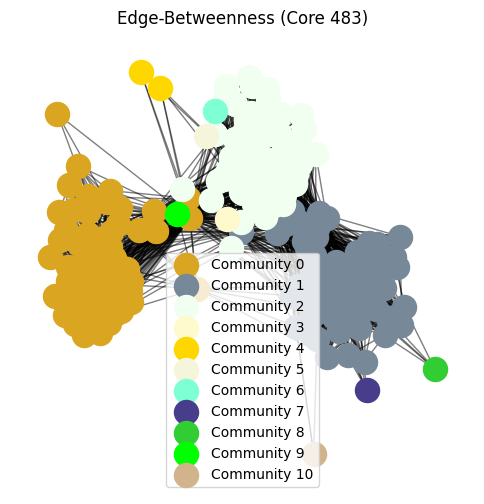

Edge-Betweenness modularity (core removed): 0.5154


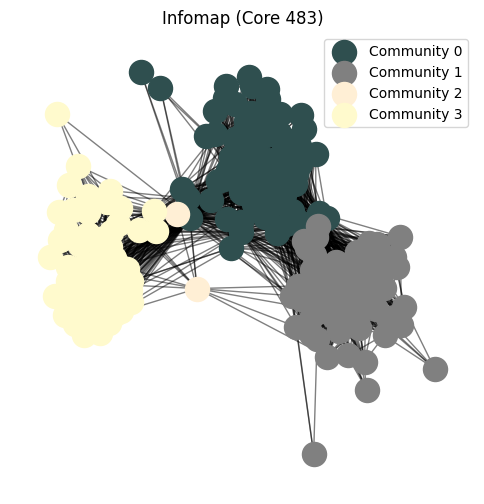

Infomap modularity (core removed): 0.5434
=== Core node 1086 (Core node removed) ===


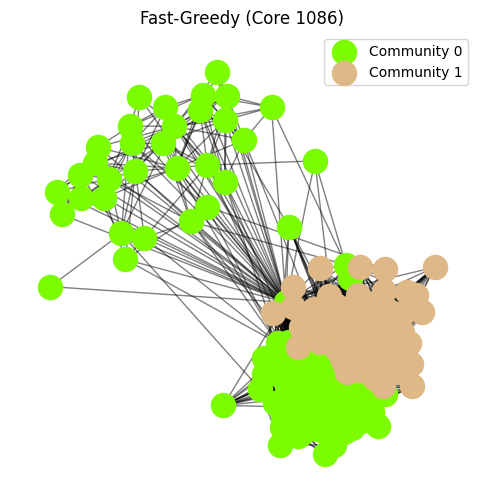

Fast-Greedy modularity (core removed): 0.1482


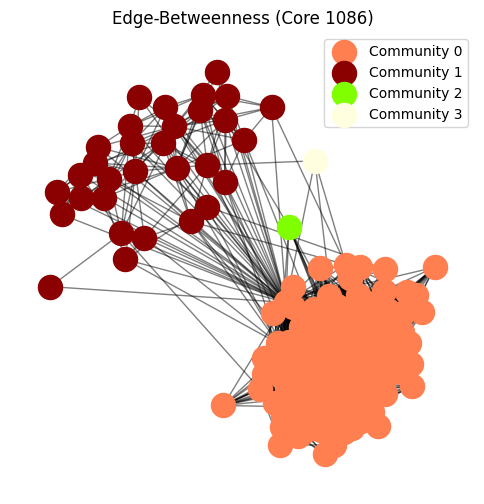

Edge-Betweenness modularity (core removed): 0.0325


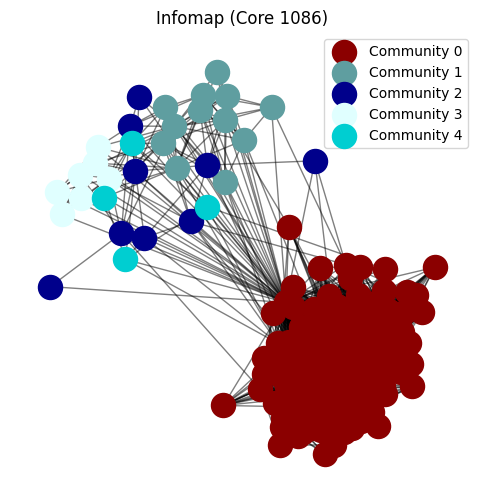

Infomap modularity (core removed): 0.0272


In [16]:
for core in core_nodes:
    print(f"=== Core node {core} (Core node removed) ===")
    G_personal = nx.ego_graph(G, core)
    G_personal_removed = G_personal.copy()
    G_personal_removed.remove_node(core)

    # Now use the same functions as before
    mod_fg = fast_greedy(G_personal_removed, core)
    print(f"Fast-Greedy modularity (core removed): {mod_fg:.4f}")

    mod_eb = edge_betweenness(G_personal_removed, core)
    print(f"Edge-Betweenness modularity (core removed): {mod_eb:.4f}")

    mod_im = infomap(G_personal_removed, core)
    print(f"Infomap modularity (core removed): {mod_im:.4f}")

# Question 11
Write an expression relating the Embeddedness between the core node and
a non-core node to the degree of the non-core node in the personalized network of the core node

The embeddedness between a core node $v_{core}$ and the non-core node $v_i$ the number of mutual neighbouts they share

$\text{Embeddedness}(v_i, v_{\text{core}}) = |\text{Neighbors}(v_i) \cap \text{Neighbors}(v_{\text{core}})|$

In an ego-graph, since the non-core nodes are connected to the core nodes, this expression can simplilify to  


$\text{Embeddedness}(v_i, v_{\text{core}}) = \text{Degree}(v_i) - 1$



# Question 12

For each of the core node’s personalized network (use the same core nodes as
Question 9), plot the distribution histogram of embeddedness and dispersion. In this question, you
will have 10 plots.


In [17]:
# Code for Q12

# Compute embeddedness
def compute_embeddedness(G_personal, core_node, target_node):
    core_neighbors = set(G_personal.neighbors(core_node))
    target_neighbors = set(G_personal.neighbors(target_node))
    mutual_friends = core_neighbors.intersection(target_neighbors)
    return len(mutual_friends)

# Compute dispersion
def compute_dispersion(G_personal, core_node, target_node):
    # Find mutual friends
    core_neighbors = set(G_personal.neighbors(core_node))
    target_neighbors = set(G_personal.neighbors(target_node))
    mutual_friends = list(core_neighbors.intersection(target_neighbors))

    if len(mutual_friends) < 2:
        return 0  # Dispersion is zero if fewer than 2 mutual friends

    # Create modified graph
    G_modified = G_personal.copy()
    G_modified.remove_node(core_node)
    G_modified.remove_node(target_node)

    dispersion = 0
    for i in range(len(mutual_friends)):
        for j in range(i+1, len(mutual_friends)):
            try:
                dist = nx.shortest_path_length(G_modified, mutual_friends[i], mutual_friends[j])
                dispersion += dist
            except nx.NetworkXNoPath:
                # If no path exists, skip
                pass

    return dispersion

In [31]:
def compute_embeddedness(G_personal, core_node, target_node, neighbor_dict=None):
    if neighbor_dict is None:
        core_neighbors = set(G_personal.neighbors(core_node))
        target_neighbors = set(G_personal.neighbors(target_node))
    else:
        core_neighbors = neighbor_dict[core_node]
        target_neighbors = neighbor_dict[target_node]
    return len(core_neighbors.intersection(target_neighbors))

def compute_dispersion(G_personal, core_node, target_node, neighbor_dict=None):
    if neighbor_dict is None:
        core_neighbors = set(G_personal.neighbors(core_node))
        target_neighbors = set(G_personal.neighbors(target_node))
    else:
        core_neighbors = neighbor_dict[core_node]
        target_neighbors = neighbor_dict[target_node]

    mutual_friends = list(core_neighbors.intersection(target_neighbors))

    if len(mutual_friends) < 2:
        return 0

    valid_nodes = [n for n in G_personal.nodes() if n != core_node and n != target_node]
    G_modified = G_personal.subgraph(valid_nodes)

    dispersion = 0
    for i in range(len(mutual_friends)):
        lengths = nx.single_source_shortest_path_length(G_modified, mutual_friends[i])
        for j in range(i + 1, len(mutual_friends)):
            if mutual_friends[j] in lengths:
                dispersion += lengths[mutual_friends[j]]

    return dispersion




In [34]:
import networkx as nx

# Compute embeddedness
def compute_embeddedness(G_personal, core_node, target_node, neighbor_dict=None):
    if neighbor_dict is None:
        core_neighbors = set(G_personal.neighbors(core_node))
        target_neighbors = set(G_personal.neighbors(target_node))
    else:
        core_neighbors = neighbor_dict[core_node]
        target_neighbors = neighbor_dict[target_node]

    mutual_friends = core_neighbors.intersection(target_neighbors)
    return len(mutual_friends)

# Compute dispersion
def compute_dispersion(G_personal, core_node, target_node, neighbor_dict=None):
    if neighbor_dict is None:
        core_neighbors = set(G_personal.neighbors(core_node))
        target_neighbors = set(G_personal.neighbors(target_node))
    else:
        core_neighbors = neighbor_dict[core_node]
        target_neighbors = neighbor_dict[target_node]

    mutual_friends = list(core_neighbors.intersection(target_neighbors))

    if len(mutual_friends) < 2:
        return 0

    # same logic as before: remove core and target
    G_modified = G_personal.copy()
    G_modified.remove_node(core_node)
    G_modified.remove_node(target_node)

    dispersion = 0
    for i in range(len(mutual_friends)):
        # faster than calling shortest_path_length for every pair
        lengths = nx.single_source_shortest_path_length(G_modified, mutual_friends[i])

        for j in range(i + 1, len(mutual_friends)):
            if mutual_friends[j] in lengths:
                dispersion += lengths[mutual_friends[j]]

    return dispersion

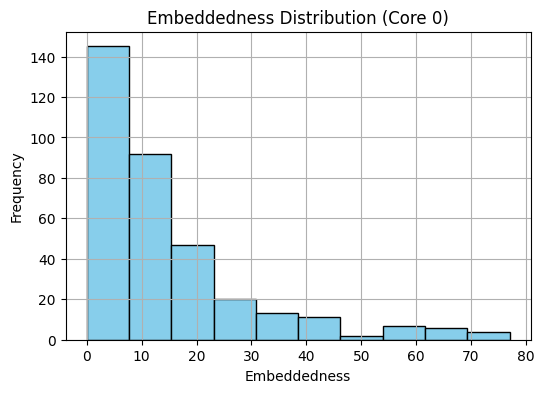

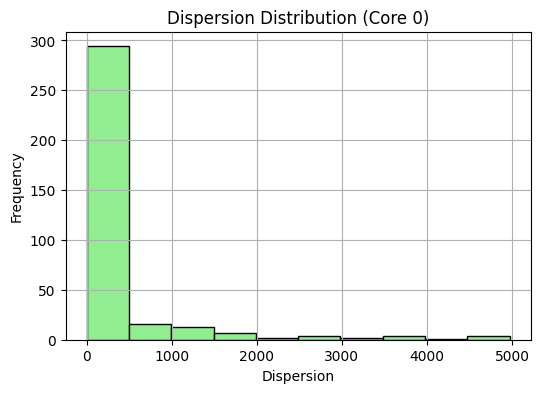

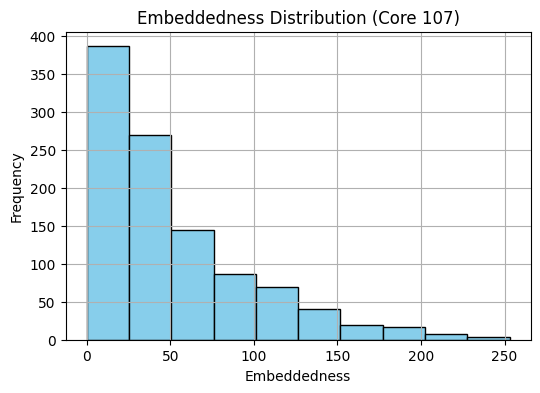

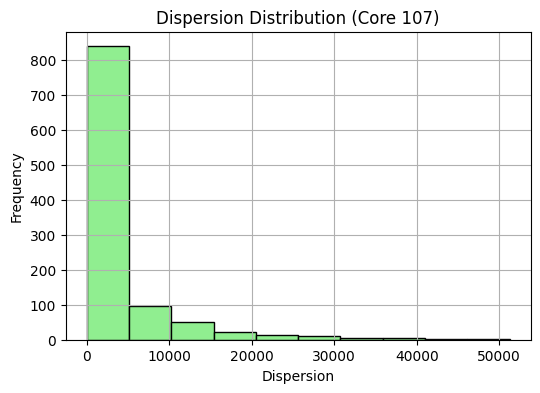

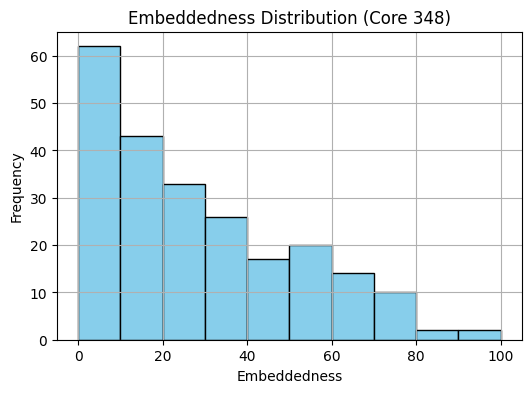

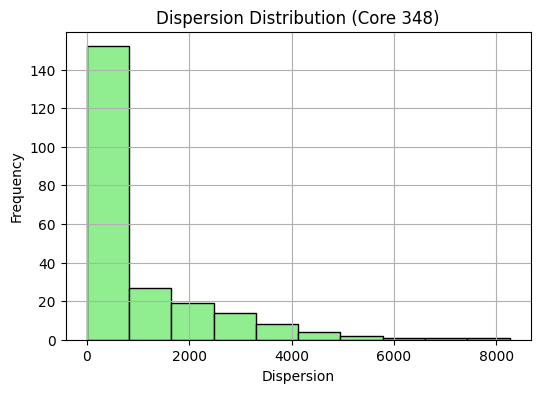

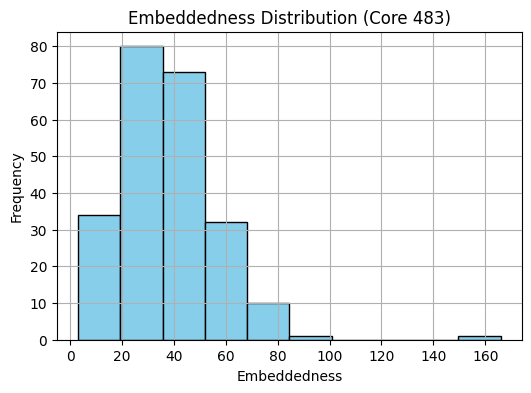

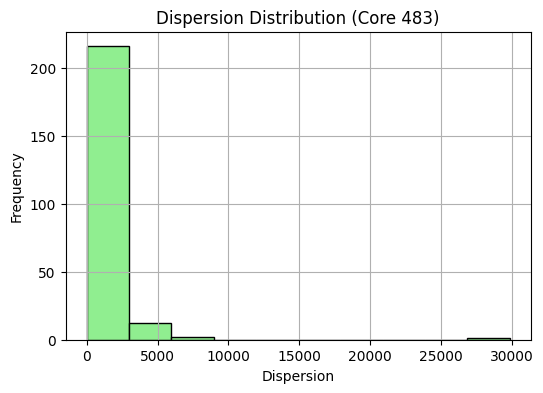

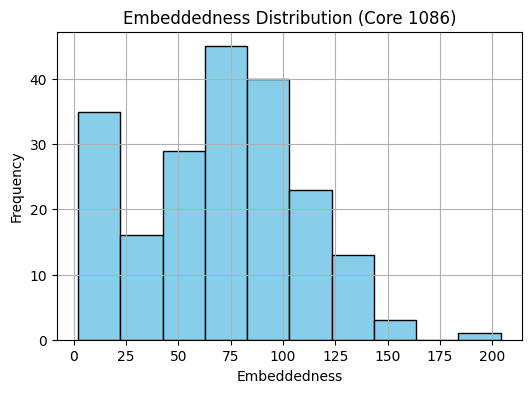

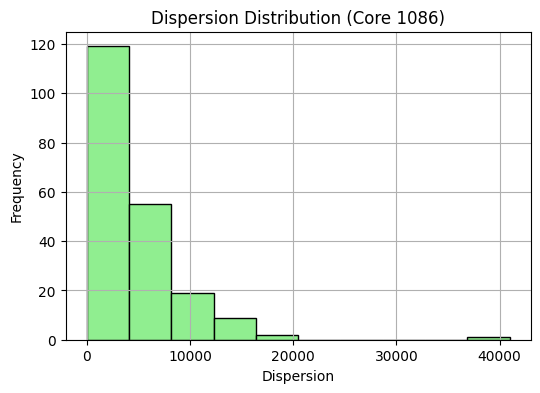

In [35]:
for core in core_nodes:
    G_personal = nx.ego_graph(G, core)
    neighbors = list(G_personal.neighbors(core))
    neighbor_dict = {n: set(G_personal.neighbors(n)) for n in G_personal.nodes()}

    embeddedness_list = []
    dispersion_list = []

    for v in neighbors:
        emb = compute_embeddedness(G_personal, core, v, neighbor_dict)
        disp = compute_dispersion(G_personal, core, v, neighbor_dict)
        embeddedness_list.append(emb)
        dispersion_list.append(disp)


    # Plot Embeddedness Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(embeddedness_list, bins=10, color='skyblue', edgecolor='black')
    plt.title(f"Embeddedness Distribution (Core {core})")
    plt.xlabel("Embeddedness")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Plot Dispersion Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(dispersion_list, bins=10, color='lightgreen', edgecolor='black')
    plt.title(f"Dispersion Distribution (Core {core})")
    plt.xlabel("Dispersion")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


In [23]:
G = ig.Graph.TupleList(G.edges(), directed=False)
for core in core_nodes:
    G_personal = nx.ego_graph(G, core)
    neighbors = list(G_personal.neighbors(core))

    embeddedness_list = []
    dispersion_list = []

    for v in neighbors:
        emb = compute_embeddedness(G_personal, core, v)
        disp = compute_dispersion(G_personal, core, v)
        embeddedness_list.append(emb)
        dispersion_list.append(disp)

    # Plot Embeddedness Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(embeddedness_list, bins=10, color='skyblue', edgecolor='black')
    plt.title(f"Embeddedness Distribution (Core {core})")
    plt.xlabel("Embeddedness")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # Plot Dispersion Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(dispersion_list, bins=10, color='lightgreen', edgecolor='black')
    plt.title(f"Dispersion Distribution (Core {core})")
    plt.xlabel("Dispersion")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

TypeError: argument of type 'Graph' is not iterable